In [1]:
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import xarray as xr
import geopandas as gpd
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob
import seaborn as sns
from IPython.display import HTML
import regionmask

Suggested Figures to complete the story:
-

Bar charts statewide seasonality (monthly counts) NORMALIZED ?Hours and precip sum
- Recent climate normal statewide and Regional of focus 
- ERA5 31km and 4km (comparing)


Decadal counts storm hours --Hours and precip sum
- 4km decadal periods 1960-2010’s 
- regional and statewide 

Numbers of extremes by decade? 
- Above 5th percentile ?


Case study of exploring comparison between ASOS and ERA5 4km 
- Snotel Site Comparison
	2021 and 2011 


Loading in the Data 
-

In [2]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)

Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']

FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

In [3]:
'''path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/'
compare=f'ROS_Monthly_*.nc'
file_list = sorted(glob.glob(os.path.join(path, compare)))
combined_ds=xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')
#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)

combined_ds = combined_ds.where(oceanmask != 17)
era5_4km=combined_ds

era54kmlat = combined_ds['XLAT'].values
era54kmlon = combined_ds['XLONG'].values

ROS_Tally_era5_4km=np.sum(era5_4km['ros_tally'],axis=1)
ROS_Tally_seasonal_era5_4km=np.mean(ROS_Tally_era5_4km,axis=0)

ROS_Rain_sum_era5_4km=np.sum(era5_4km['rain_ros_sum'],axis=1)
ROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)

lat = combined_ds['XLAT'].values
lon = combined_ds['XLONG'].values'''

'path=\'/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/\'\ncompare=f\'ROS_Monthly_*.nc\'\nfile_list = sorted(glob.glob(os.path.join(path, compare)))\ncombined_ds=xr.open_mfdataset(file_list, combine=\'by_coords\',engine=\'netcdf4\')\n\nos.chdir("/import/beegfs/CMIP6/wrf_era5")\ngeo_em_path = "geo_em.d02.nc"\ngeo = xr.open_dataset(geo_em_path)\noceanmask=geo[\'LU_INDEX\']\noceanmask=oceanmask.squeeze(dim=\'Time\')\n#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)\n\ncombined_ds = combined_ds.where(oceanmask != 17)\nera5_4km=combined_ds\n\nera54kmlat = combined_ds[\'XLAT\'].values\nera54kmlon = combined_ds[\'XLONG\'].values\n\nROS_Tally_era5_4km=np.sum(era5_4km[\'ros_tally\'],axis=1)\nROS_Tally_seasonal_era5_4km=np.mean(ROS_Tally_era5_4km,axis=0)\n\nROS_Rain_sum_era5_4km=np.sum(era5_4km[\'rain_ros_sum\'],axis=1)\nROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)\n\nlat = combined_ds[\'XLAT\'].values\nlon = combined_ds[\'XLONG\'].values'

In [4]:
#Regridded ERA5 31km
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)

In [5]:
os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')

era5_4km = era5_4km.where(oceanmask != 17)
regridded_era5 = regridded_era5.where(oceanmask != 17)

In [6]:
seasons=era5_4km['season']
lat=era5_4km['XLAT']
lon=era5_4km['XLONG']

At single point #not initally used but brougbt over incase I need it !

In [7]:
'''def compute_ros_hours_normalized(data):
    """Compute total ROS hours per season, number of pixels with ROS per season,
    and normalized ROS hours (total / number of pixels)
    
    seasons : season labels
    ros_hourly_totals_climatology  Total ROS hours per season
    n_pixels_per_season : Number of pixels with ROS per season
    ros_hours_normalized : Normalized ROS hours per season"""

    ros_hourly_totals_climatology = []
    n_pixels_per_season = []

    for i in range(len(data.season)):
        ros_this_season = data.isel(season=i)
        # Total ROS hours
        total = ros_this_season.sum().compute().item()
        ros_hourly_totals_climatology.append(total)
        # Count pixels with ROS (> 0)
        grid_with_ros = ros_this_season > 0
        n_pixels = grid_with_ros.sum().compute().item()
        n_pixels_per_season.append(n_pixels)

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals_climatology, n_pixels_per_season)]

    seasons = [str(s) for s in data.season.values]

    return seasons, ros_hourly_totals_climatology, n_pixels_per_season, ros_hours_normalized'''
    
    
#seasons, totals_4s, n_pixels_4s, statewide_4km_normalized = compute_ros_hours_normalized(ros_seasonal_total_4km)

#seasons, totals_31s, n_pixels_31s, statewide_31km_normalized = compute_ros_hours_normalized(ros_seasonal_total_31km)

'def compute_ros_hours_normalized(data):\n    """Compute total ROS hours per season, number of pixels with ROS per season,\n    and normalized ROS hours (total / number of pixels)\n    \n    seasons : season labels\n    ros_hourly_totals_climatology  Total ROS hours per season\n    n_pixels_per_season : Number of pixels with ROS per season\n    ros_hours_normalized : Normalized ROS hours per season"""\n\n    ros_hourly_totals_climatology = []\n    n_pixels_per_season = []\n\n    for i in range(len(data.season)):\n        ros_this_season = data.isel(season=i)\n        # Total ROS hours\n        total = ros_this_season.sum().compute().item()\n        ros_hourly_totals_climatology.append(total)\n        # Count pixels with ROS (> 0)\n        grid_with_ros = ros_this_season > 0\n        n_pixels = grid_with_ros.sum().compute().item()\n        n_pixels_per_season.append(n_pixels)\n\n    ros_hours_normalized = [\n        total / n if n > 0 else 0\n        for total, n in zip(ros_hourly_total

TESTING
-

In [8]:
def compute_ros_hours_normalized_monthly(data, month_numbers, month_labels):
    ros_hourly_totals = []
    n_pixels_per_month = []

    for m in month_numbers:
        ros_this_month = data.sel(month=m).mean(axis=0)
        total = ros_this_month.sum().compute().item()
        ros_hourly_totals.append(total)

        grid_with_ros = ros_this_month > 0
        n_pixels = grid_with_ros.sum().compute().item()
        n_pixels_per_month.append(n_pixels)

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals, n_pixels_per_month)
    ]
    return month_labels, ros_hourly_totals, n_pixels_per_month, ros_hours_normalized

In [9]:
monthlist = ['November','December','January','February','March']
monthnumberlist = [11,12,1,2,3]

months, totals_4km, n_pixels_4km, normalized_4km = \
    compute_ros_hours_normalized_monthly(
        era5_4km['ros_tally'],
        monthnumberlist,
        monthlist
    )
    
months, totals_31km, n_pixels_31km, normalized_31km = \
    compute_ros_hours_normalized_monthly(
        regridded_era5['ros_tally'],
        monthnumberlist,
        monthlist
    )

Breaking into two climate normals
- 

In [10]:
era5_4km_1951_1980 = era5_4km.sel(season=slice('1951-1952', '1980-1981'))
era5_4km_1991_2020 = era5_4km.sel(season=slice('1991-1992', '2020-2021'))
regridded_era5_1951_1980 = regridded_era5.sel(season=slice('1951-1952', '1980-1981'))
regridded_era5_1991_2020 = regridded_era5.sel(season=slice('1991-1992', '2020-2021'))

months, totals_1951_1980_31km, n_pixels_1951_1980_31km, normalized_1951_1980_31km = \
    compute_ros_hours_normalized_monthly(
        regridded_era5_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, totals_1991_2020_31km, n_pixels_1991_2020_31km, normalized_1991_2020_31km = \
    compute_ros_hours_normalized_monthly(
        regridded_era5_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


months, totals_1951_1980_4km, n_pixels_1951_1980_4km, normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months,totals_1991_2020_4km, n_pixels_1991_2020_4km, normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


To explore Bar charts and statewide seasonality 
-


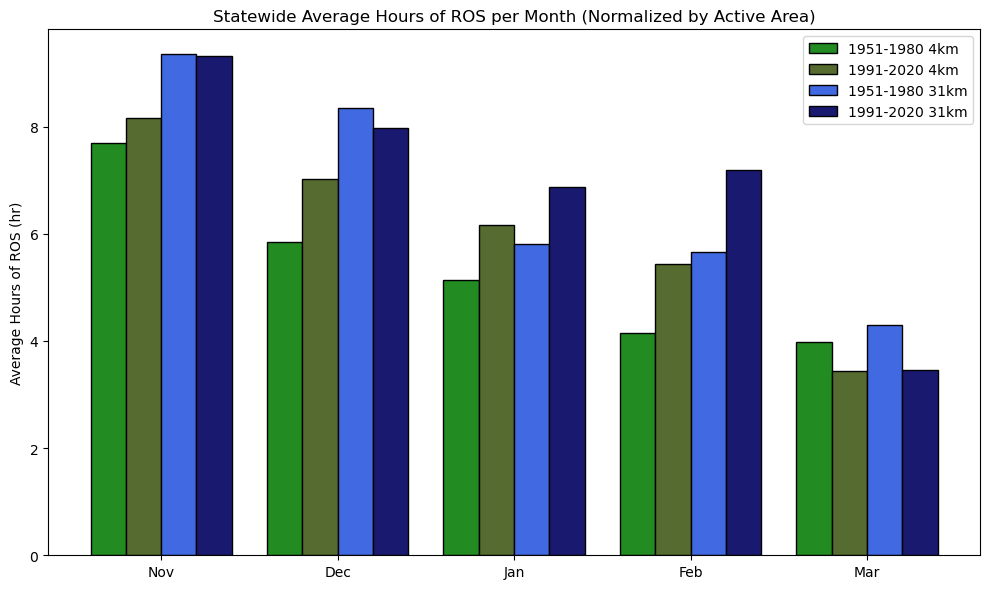

In [11]:
month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))
width = 0.2
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - 1.5*width, normalized_1951_1980_4km, width, color='forestgreen', edgecolor='black', label='1951-1980 4km')
ax.bar(x - 0.5*width, normalized_1991_2020_4km, width, color='darkolivegreen', edgecolor='black', label='1991-2020 4km')
ax.bar(x + 0.5*width, normalized_1951_1980_31km, width, color='royalblue', edgecolor='black', label='1951-1980 31km')
ax.bar(x + 1.5*width, normalized_1991_2020_31km, width, color='midnightblue', edgecolor='black', label='1991-2020 31km')

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Average Hours of ROS (hr)')
ax.set_title('Statewide Average Hours of ROS per Month (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

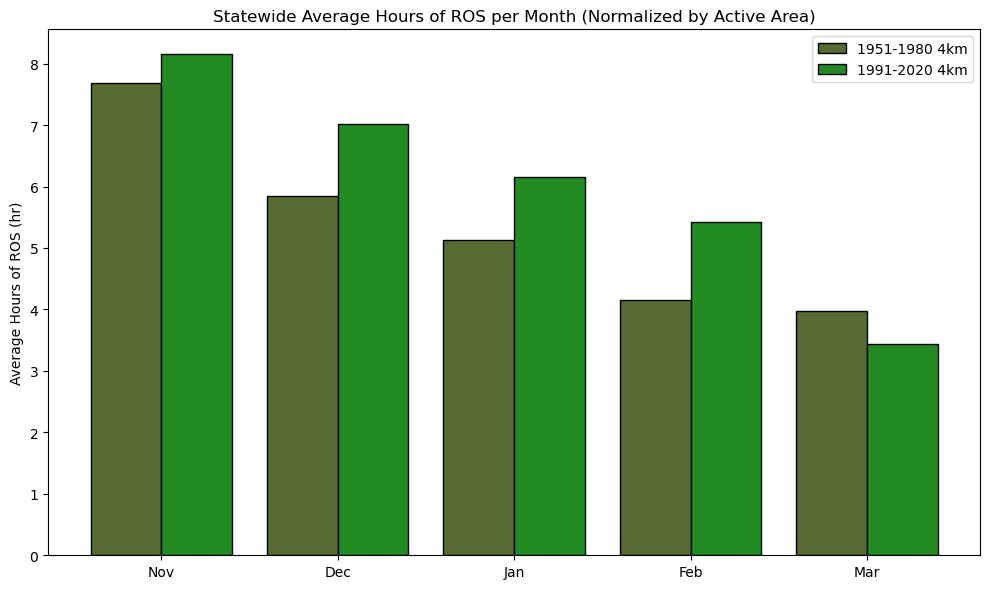

In [12]:
month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))
width = 0.4
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x -.5*width, normalized_1951_1980_4km, width, color='darkolivegreen', edgecolor='black', label='1951-1980 4km')
ax.bar(x + 0.5*width, normalized_1991_2020_4km, width, color='forestgreen', edgecolor='black', label='1991-2020 4km')

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Average Hours of ROS (hr)')
ax.set_title('Statewide Average Hours of ROS per Month (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

Regional Analysis 
-

In [13]:
def apply_borough_mask(datasets, shapefile):
    masked_datasets = {}
    for month, data in datasets.items():
        masked = borough_land_mask(shapefile, data, data.XLAT, data.XLONG)
        masked_datasets[month] = masked
    return masked_datasets

In [14]:
def borough_land_mask(shapefile,data):
    mask = regionmask.mask_geopandas(shapefile, data.XLONG, data.XLAT)
    data_masked = data.where(~np.isnan(mask))
    return data_masked

In [15]:
era5_4km_1951_1980 = era5_4km.sel(season=slice('1951-1952', '1980-1981'))
era5_4km_1991_2020 = era5_4km.sel(season=slice('1991-1992', '2020-2021'))
regridded_era5_1951_1980 = regridded_era5.sel(season=slice('1951-1952', '1980-1981'))
regridded_era5_1991_2020 = regridded_era5.sel(season=slice('1991-1992', '2020-2021'))

In [16]:
bet_era5_4km_1951_1980=borough_land_mask(Bethel_boundary, era5_4km_1951_1980)
bet_era5_4km_1991_2020=borough_land_mask(Bethel_boundary, era5_4km_1991_2020)

months, bet_totals_1951_1980_4km, bet_n_pixels_1951_1980_4km, bet_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        bet_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, bet_totals_1991_2020_4km, bet_n_pixels_1991_2020_4km, bet_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        bet_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


fai_era5_4km_1951_1980=borough_land_mask(FNSB_boundary, era5_4km_1951_1980)
fai_era5_4km_1991_2020=borough_land_mask(FNSB_boundary, era5_4km_1991_2020)

months, fai_totals_1951_1980_4km, fai_n_pixels_1951_1980_4km, fai_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        fai_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, fai_totals_1991_2020_4km, fai_n_pixels_1991_2020_4km, fai_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        fai_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


anc_era5_4km_1951_1980=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1951_1980)
anc_era5_4km_1991_2020=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1991_2020)


months, anc_totals_1951_1980_4km, anc_n_pixels_1951_1980_4km, anc_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months,anc_totals_1991_2020_4km, anc_n_pixels_1991_2020_4km, anc_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


In [17]:
'''
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessary for 3D plotting

borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))
width = 0.3
depth = 0.3 

fig = plt.figure(figsize=(30, 8))

ax = fig.add_subplot(111, projection='3d')

offsets = {"1951-1980": -0.1,
        "1991-2020": 0.15}

y_positions = {
    "Fairbanks": 0,
    "Anchorage": 3,
    'Statewide': 1,
    "Bethel": 2
}
# ---- Anchorage ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_normalized_1951_1980_4km, 
         color=borough_colors["Anchorageold"],  edgecolor='black', label='Anchorage 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_normalized_1991_2020_4km, 
         color=borough_colors["Anchoragenew"], edgecolor='black', label='Anchorage 1991-2020')
#---- Statewide ----

ax.bar3d(x + offsets["1951-1980"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, normalized_1951_1980_4km, 
         color=borough_colors["Statewideold"],  edgecolor='black', label='Statewide 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, normalized_1991_2020_4km, 
         color=borough_colors["Statewidenew"], edgecolor='black', label='Statewide 1991-2020')


# ---- Fairbanks ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_normalized_1951_1980_4km, 
         color=borough_colors["Fairbanksold"],  edgecolor='black', label='Fairbanks 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_normalized_1991_2020_4km, 
         color=borough_colors["Fairbanksnew"], edgecolor='black', label='Fairbanks 1991-2020')

# ---- Bethel ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_normalized_1951_1980_4km, 
         color=borough_colors["Bethelold"], edgecolor='black', label='Bethel 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_normalized_1991_2020_4km, 
         color=borough_colors["Bethelnew"], edgecolor='black', label='Bethel 1991-2020')


# Set axis labels
ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=12)
ax.set_yticks([0.5,1.5,2.5,3.5])
ax.set_yticklabels([' Fairbanks',' Statewide','Bethel','   Anchorage'], fontsize=12)
ax.set_zlabel('Average Hours of ROS (hr)', fontsize=14, rotation=90)
ax.set_title('Average Hours of ROS by Borough\n(Normalized by Active Area)', y=0.99,fontsize=16)
#ax.legend( loc='upper left', fontsize=10)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(left=0.1, right=0.9)
plt.show()
'''

'\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D  # necessary for 3D plotting\n\nborough_colors = {\n    \'Anchorageold\': "#5f7783",   # light blue\n    "Anchoragenew": "#68d9eb",   # teal green\n    "Fairbanksnew": "#e3985e",   # orange\n    "Fairbanksold": "#A44D0A",   # orange\n    "Bethelnew": "#9c98d2",      # purple\n    "Bethelold": "#504e73",      # purple\n    "Statewidenew": "#0072B2" ,   # blue\n    "Statewideold": "#004c99"     # dark blue\n}\n\nmonth_labels = [\'Nov\', \'Dec\', \'Jan\', \'Feb\', \'Mar\']\nx = np.arange(len(month_labels))\nwidth = 0.3\ndepth = 0.3 \n\nfig = plt.figure(figsize=(30, 8))\n\nax = fig.add_subplot(111, projection=\'3d\')\n\noffsets = {"1951-1980": -0.1,\n        "1991-2020": 0.15}\n\ny_positions = {\n    "Fairbanks": 0,\n    "Anchorage": 3,\n    \'Statewide\': 1,\n    "Bethel": 2\n}\n# ---- Anchorage ----\nax.bar3d(x + offsets["1951-1980"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x),

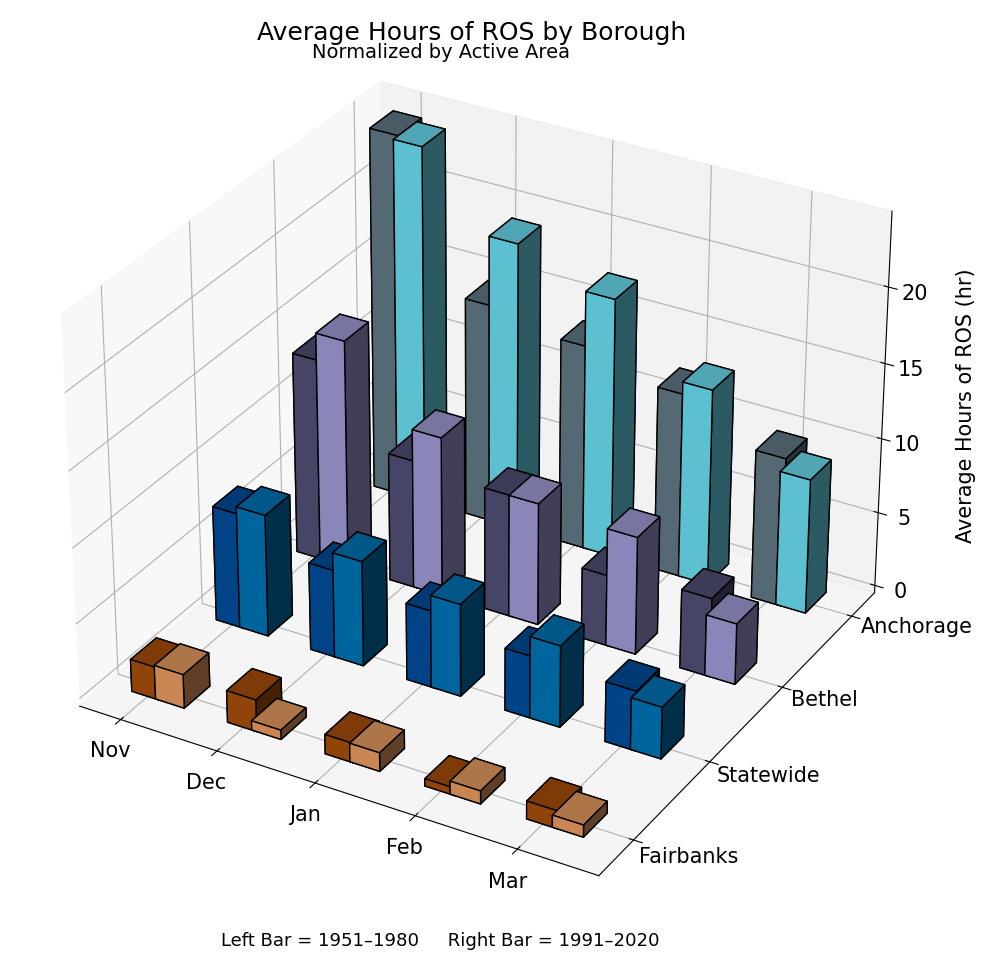

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessary for 3D plotting
from matplotlib.patches import Patch

borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))
width = 0.3
depth = 0.3 


fig = plt.figure(figsize=(25, 12)) 
ax = fig.add_subplot(111, projection='3d')


offsets = {"1951-1980": -0.1,
        "1991-2020": 0.15}

y_positions = {
    "Fairbanks": 0,
    "Anchorage": 3,
    'Statewide': 1,
    "Bethel": 2
}
# ---- Anchorage ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_normalized_1951_1980_4km, 
         color=borough_colors["Anchorageold"],  edgecolor='black', label='Anchorage 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_normalized_1991_2020_4km, 
         color=borough_colors["Anchoragenew"], edgecolor='black', label='Anchorage 1991-2020')
#---- Statewide ----

ax.bar3d(x + offsets["1951-1980"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, normalized_1951_1980_4km, 
         color=borough_colors["Statewideold"],  edgecolor='black', label='Statewide 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, normalized_1991_2020_4km, 
         color=borough_colors["Statewidenew"], edgecolor='black', label='Statewide 1991-2020')


# ---- Fairbanks ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_normalized_1951_1980_4km, 
         color=borough_colors["Fairbanksold"],  edgecolor='black', label='Fairbanks 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_normalized_1991_2020_4km, 
         color=borough_colors["Fairbanksnew"], edgecolor='black', label='Fairbanks 1991-2020')

# ---- Bethel ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_normalized_1951_1980_4km, 
         color=borough_colors["Bethelold"], edgecolor='black', label='Bethel 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_normalized_1991_2020_4km, 
         color=borough_colors["Bethelnew"], edgecolor='black', label='Bethel 1991-2020')


# Set axis labels
ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=15)

yticks = [0.2, 1.2, 2.2, 3.2]
labels = ['Fairbanks','Statewide','Bethel','Anchorage']
ax.set_yticklabels([])
ax.set_yticks(yticks)

for y, label in zip(yticks, labels):
    ax.text(x[-1]+1.2 , y-.5, 2, label, fontsize=15, ha='left', va='center')

#ax.set_yticks([0.2,1.2,2.2,3.2])
#ax.set_yticklabels(['  Fairbanks','   Statewide','Bethel','    Anchorage'], fontsize=12)
#ax.set_zlabel('Average Hours of ROS (hr)', fontsize=12, rotation=90)
ax.tick_params(axis='z', labelsize=15)
fig.text(0.71, 0.55, 'Average Hours of ROS (hr)', rotation=90, fontsize=15, va='center', ha='center')
#ax.set_title('Average Hours of ROS by Borough\n(Normalized by Active Area)', y=0.99,fontsize=15)

ax.set_title('Average Hours of ROS by Borough', fontsize=18, pad=20,y=1.019)  
fig.text(0.5, 0.84, 'Normalized by Active Area', ha='center', fontsize=14)

fig.text(.5, .1, "Left Bar = 1951–1980     Right Bar = 1991–2020", ha='center', fontsize=13)
plt.show()

In [19]:
anc_era5_4km_1951_1980=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1951_1980)
anc_era5_4km_1991_2020=borough_land_mask(Mun_of_Anc_boundary, era5_4km_1991_2020)
anc_regridded_era5_1951_1980=borough_land_mask(Mun_of_Anc_boundary, regridded_era5_1951_1980)
anc_regridded_era5_1991_2020=borough_land_mask(Mun_of_Anc_boundary, regridded_era5_1991_2020)


months, and_totals_1951_1980_31km, anc_n_pixels_1951_1980_31km, anc_normalized_1951_1980_31km = \
    compute_ros_hours_normalized_monthly(
        anc_regridded_era5_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months, anc_totals_1991_2020_31km, anc_n_pixels_1991_2020_31km, anc_normalized_1991_2020_31km = \
    compute_ros_hours_normalized_monthly(
        anc_regridded_era5_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  

months, anc_totals_1951_1980_4km, anc_n_pixels_1951_1980_4km, anc_normalized_1951_1980_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1951_1980['ros_tally'],
        monthnumberlist,
        monthlist)

months,anc_totals_1991_2020_4km, anc_n_pixels_1991_2020_4km, anc_normalized_1991_2020_4km = \
    compute_ros_hours_normalized_monthly(
        anc_era5_4km_1991_2020['ros_tally'],
        monthnumberlist,
        monthlist)  


In [20]:
'''
Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']
'''

"\nMun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']\nBethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']\nMat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']\nDenali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']\n"

In [21]:
np.sum(anc_normalized_1951_1980_4km)

75.22683781983459

In [22]:
anc_1951_seasonal_ros=np.sum(anc_normalized_1951_1980_4km)
anc_1991_seasonal_ros=np.sum(anc_normalized_1991_2020_4km)

bet_1951_seasonal_ros=np.sum(bet_normalized_1951_1980_4km)
bet_1991_seasonal_ros=np.sum(bet_normalized_1991_2020_4km)

fai_1951_seasonal_ros=np.sum(fai_normalized_1951_1980_4km)
fai_1991_seasonal_ros=np.sum(fai_normalized_1991_2020_4km)

statewide_1951_seasonal_ros=np.sum(normalized_1951_1980_4km)
statewide_1991_seasonal_ros=np.sum(normalized_1991_2020_4km)


In [23]:
anc_1951_seasonal_ros

75.22683781983459

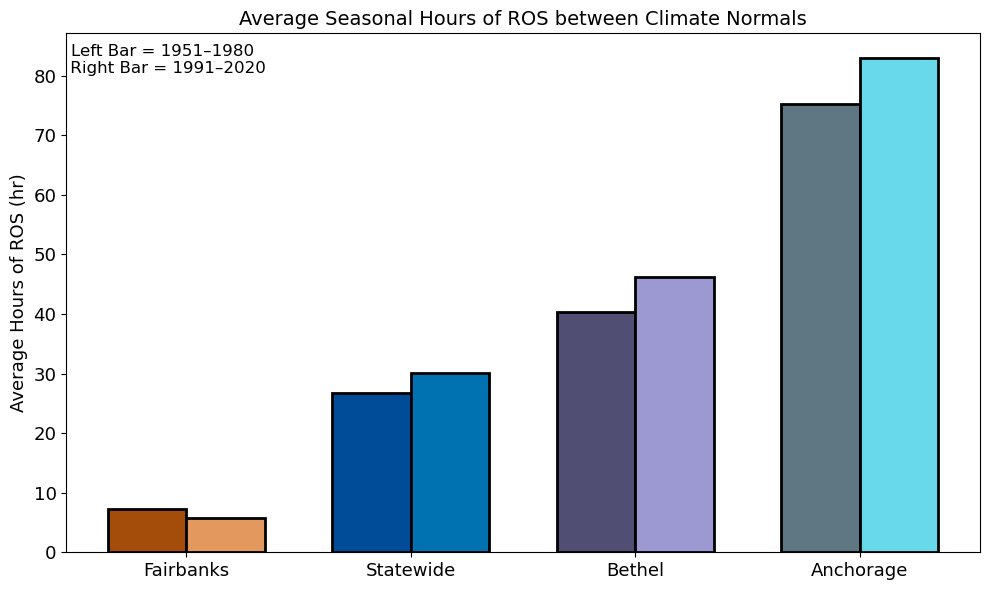

In [24]:

borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

labels = ['Fairbanks','Statewide','Bethel','Anchorage']
x = np.arange(len(labels))
width = 0.35  # width of each bar

# Values per period
old_ros = [fai_1951_seasonal_ros, statewide_1951_seasonal_ros, bet_1951_seasonal_ros, anc_1951_seasonal_ros]
new_ros = [fai_1991_seasonal_ros, statewide_1991_seasonal_ros, bet_1991_seasonal_ros, anc_1991_seasonal_ros]

fig, ax = plt.subplots(figsize=(10,6))

# Plot bars
ax.bar(x - width/2, old_ros, width, color=[borough_colors['Fairbanksold'], borough_colors['Statewideold'], borough_colors['Bethelold'], borough_colors['Anchorageold']], edgecolor='black',  linewidth=2, label='1951-1980')
ax.bar(x + width/2, new_ros, width, color=[borough_colors['Fairbanksnew'], borough_colors['Statewidenew'], borough_colors['Bethelnew'], borough_colors['Anchoragenew']], edgecolor='black',   linewidth=2,label='1991-2020')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=13)
ax.set_ylabel('Average Hours of ROS (hr)',fontsize=13)
ax.set_title('Average Seasonal Hours of ROS between Climate Normals', fontsize=14)
ax.tick_params(axis='y', labelsize=13)
fig.text(0.17, 0.87, "Left Bar = 1951–1980 \n Right Bar = 1991–2020", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [25]:

nov_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=3),axis=0)

nov_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=11),axis=0)
dec_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=12),axis=0)
jan_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=1),axis=0)
feb_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=2),axis=0)
mar_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=3),axis=0)

nov_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=3),axis=0)

elevation = geo['HGT_M'].isel(Time=0)

In [27]:
era5_4km

<xarray.Dataset> Size: 6GB
Dimensions:              (season: 73, month: 5, south_north: 450,
                          west_east: 420, interp_level: 3)
Coordinates:
  * season               (season) <U9 3kB '1950-1951' ... '2022-2023'
  * month                (month) int64 40B 11 12 1 2 3
    XLAT                 (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLONG                (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
  * interp_level         (interp_level) float64 24B 850.0 925.0 950.0
    month_name           (month) <U3 60B dask.array<chunksize=(5,), meta=np.ndarray>
Dimensions without coordinates: south_north, west_east
Data variables: (12/13)
    ros_tally            (season, month, south_north, west_east) float64 552MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    ros_counts           (season, month, south_north, west_east) float64 552MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    ros_days_count       (season, month, south_north, west_east) float64 552MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    rain_sum             (season, month, south_north, west_east) float32 276MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    rain_ros_sum         (season, month, south_north, west_east) float32 276MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    rain_avg             (season, month, south_north, west_east) float32 276MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    ...                   ...
    swe_avg              (season, month, south_north, west_east) float32 276MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    swe_ros_avg          (season, month, south_north, west_east) float32 276MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    T2_avg               (season, month, south_north, west_east) float32 276MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    T2_ros_avg           (season, month, south_north, west_east) float32 276MB dask.array<chunksize=(1, 5, 450, 420), meta=np.ndarray>
    temp_levels_avg      (season, month, interp_level, south_north, west_east) float32 828MB dask.array<chunksize=(1, 3, 2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg  (season, month, interp_level, south_north, west_east) float32 828MB dask.array<chunksize=(1, 3, 2, 450, 420), meta=np.ndarray>

In [28]:
months = [11, 12, 1, 2, 3]

elevation_ros = xr.Dataset({
    'ros_tally_avg_4km': era5_4km['ros_tally'].sel(month=months),
    'ros_rain_sum_avg_4km': era5_4km['rain_ros_sum'].sel(month=months),
    'ros_tally_avg_regridded_31km': regridded_era5['ros_tally'].sel(month=months),
    'ros_rain_sum_avg_regridded_31km' :regridded_era5['rain_ros_sum'].sel(month=months)
})


elevation_ros = elevation_ros.assign_coords(elevation=elevation)

bins = [0, 500, 1000, 1500, 3000]

In [29]:
ros_by_elev = elevation_ros['ros_tally_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins
).mean()

rain_by_elev = elevation_ros['ros_rain_sum_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins
).mean()

ros_by_elev_31km = elevation_ros['ros_tally_avg_regridded_31km'].groupby_bins(
    elevation_ros['elevation'], bins
).mean()

rain_by_elev_31km = elevation_ros['ros_rain_sum_avg_regridded_31km'].groupby_bins(
    elevation_ros['elevation'], bins
).mean()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_260170/339879490.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_earth', n_elev)


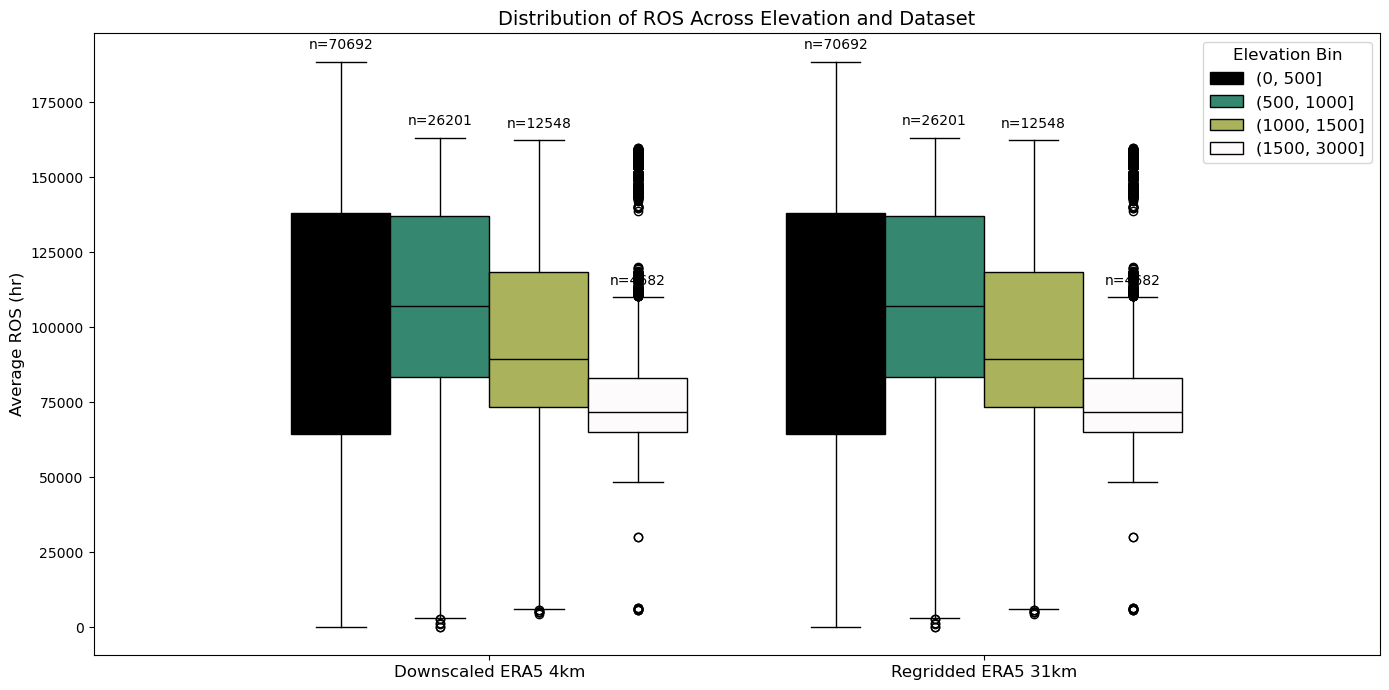

In [33]:
import matplotlib.cm as cm
ros_by_elev_4km = elevation_ros['ros_tally_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins
)

ros_by_elev_31km = elevation_ros['ros_tally_avg_regridded_31km'].groupby_bins(
    elevation_ros['elevation'], bins
)

# Get elevation bin labels
elev_labels = list(ros_by_elev_4km.groups.keys())
n_elev = len(elev_labels)

# -----------------------
# 3️⃣ Extract boxplot data and counts
# -----------------------
ros_box_4km = [np.array(ros_by_elev_4km.groups[e]).flatten() for e in elev_labels]
ros_box_31km = [np.array(ros_by_elev_31km.groups[e]).flatten() for e in elev_labels]

# Counts: number of data points in each bin
ros_count_4km = [np.array(ros_by_elev_4km.groups[e]).size for e in elev_labels]
ros_count_31km = [np.array(ros_by_elev_31km.groups[e]).size for e in elev_labels]

# -----------------------
# 4️⃣ Plotting parameters
# -----------------------
data_labels = ['Downscaled ERA5 4km', 'Regridded ERA5 31km']
n_datasets = len(data_labels)

cmap = cm.get_cmap('gist_earth', n_elev)
colors = [cmap(i) for i in range(n_elev)]

total_width = 0.8 
box_width = total_width / n_elev
x = np.arange(n_datasets) 

fig, ax = plt.subplots(figsize=(14,7))

for ei, elev in enumerate(elev_labels):
    # Data and counts for current elevation bin
    data = [ros_box_4km[ei], ros_box_31km[ei]]
    counts = [ros_count_4km[ei], ros_count_31km[ei]]
    
    positions = x - total_width/2 + ei*box_width + box_width/2

    bp = ax.boxplot(data, positions=positions, widths=box_width, patch_artist=True)
    

    for patch in bp['boxes']:
        patch.set_facecolor(colors[ei])
    for element in ['whiskers','caps','medians','fliers']:
        plt.setp(bp[element], color='black')

    for i, pos in enumerate(positions):
        top_whisker = bp['whiskers'][2*i+1].get_ydata()[1]
        ax.text(pos, top_whisker + 0.02*np.ptp(ax.get_ylim()), f'n={counts[i]}',
                ha='center', fontsize=10, color='black')

ax.set_xticks(x)
ax.set_xticklabels(data_labels, fontsize=12)
ax.set_ylabel('Average ROS (hr)', fontsize=12)
ax.set_title('Distribution of ROS Across Elevation and Dataset', fontsize=14)

# Legend for elevation bins
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=str(elev_labels[i]))
                   for i in range(n_elev)]
ax.legend(handles=legend_elements, title='Elevation Bin', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()